In [1]:
import re

In [2]:
with open("fradulent_emails.txt", "r", encoding="ISO-8859-1") as emails:
    amounts = []
    for line in emails:
        # Wir suchen nur Beträge, die mit US$ anfangen
        m = re.search(r'USD? *\$? *(\d[0-9., ]+)([M]?)', line, re.IGNORECASE)
        if not m:
            continue
        # Leerzeichen löschen
        number = re.sub(' ', '', m.group(1))

        parts = re.split(r'[.,]', number)
        # Manche Zahlen haben einen Punkt am Ende. Den ignorieren wir
        if len(parts[-1]) == 0:
            parts = parts[:-1]

        # Ist letzter Block der mit Nachkommastellen?
        # Ja, wenn min. 2 Blöcke und entweder weniger als 3 Stellen oder ein M folgt
        if len(parts) > 1 and (len(parts[-1]) < 3 or m.group(2) in ['m', 'M']):
            amount = float(''.join(parts[:-1]) + '.' + parts[-1])
        else:
            amount = float(''.join(parts))

        # M meint "Millionen USD", aber nur wenn Zahl <1000
        if m.group(2) in ['m', 'M'] and amount < 1000:
            amount *= 1000000
        
        # zusätzliche Korrekturen
        if amount < 100:
            amount *= 1000000
        if amount < 10000:
            amount *= 1000
        # Wir fügen nur Werte kleiner 1Mrd und größer 1Mio hinzu:
        if amount > 1e6 and amount <= 1e9:
            amounts.append(amount)            
        else:
            print(amount, m.group(1), m.group(2))

437000.0 43.7,000.00  
255000.0 255 
100000.0 100 
255000.0 255 
100000.0 100 
113400.0 113.4  
100000.0 100 
100000.0 100 
180000.0 180 
18000.0 18,000,00 
240000.0 240  
240000.0 240  
700000.0 700 
700000.0 700 
10500.0 10.500.000 m
350000.0 350 
700000.0 700 
855000.0 855,000 
11183.0 11.183 
200000.0 200,000.00 
200000.0 200,000.00  
200000.0 200,000.00 
200000.0 200,000.00  
0.0 00 
105000.0 105 
150000.0 150 
280000.0 0.28  
280000.0 0.28 
15000.0 15,000.00 
700000.0 700,000 
1000000.0 1000 
1000000.0 1,000,000,00  
17000.0 17,000,0 
63500.0 63,500 
750000.0 750,000 
25000.0 25,000.00  
310000.0 310 
300000.0 30.0000.00  
26700.0 26.700 
26700.0 26.700 
15500.0 15. 500  
112000.0 112 
500000.0 500 
196207197107.0 196.207.197.107 
500000.0 500,000.00 
1000000.0 1. M
1000000.0 1. M
1000000.0 1. M
1000000.0 1. M
15500.0 15.500,000  M
15500.0 15.500,000  M
20700.0 20,700,0 
20700.0 20,700, 
500000.0 500 
500000.0 500 
500000.0 500 
500000.0 500 
500000.0 500 
500000.0 500 
500000.0 

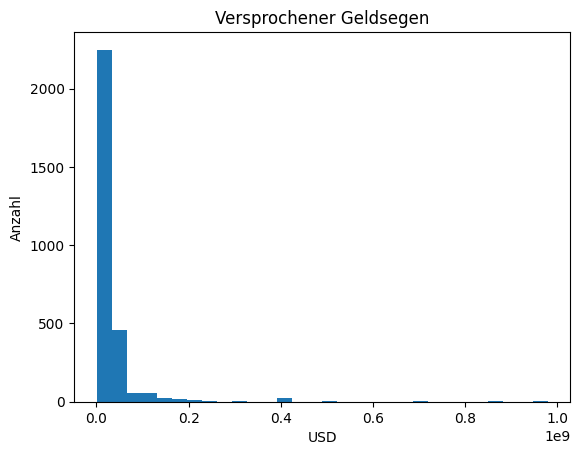

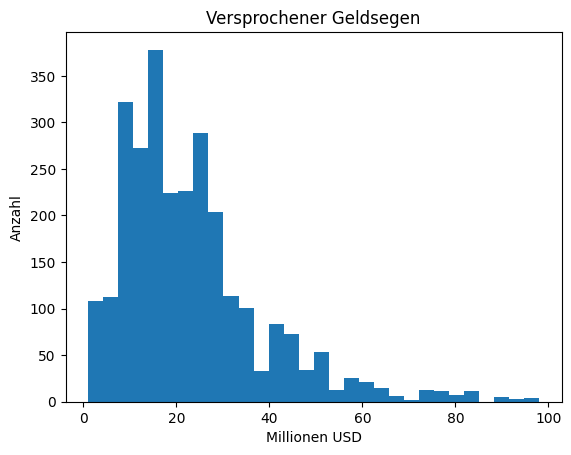

In [5]:
import matplotlib.pyplot as plt

# Ungefiltert
plt.hist(amounts, bins=30)
plt.xlabel('USD')
plt.ylabel('Anzahl')
plt.title('Versprochener Geldsegen')
plt.show()

# Zoom auf Beträge <100M USD
amountsM = [amount/1e6 for amount in amounts if amount < 100e6]
plt.hist(amountsM, bins=30)
plt.xlabel('Millionen USD')
plt.ylabel('Anzahl')
plt.title('Versprochener Geldsegen')
plt.show()